In [1]:
import zipfile
import os

zip_file_path = '/content/Gestão de pessoas.zip'
extraction_path = '/content/Gestao_de_pessoas_extracted/'

# Create the directory if it doesn't exist
os.makedirs(extraction_path, exist_ok=True)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

print(f"'{zip_file_path}' extracted to '{extraction_path}'")


'/content/Gestão de pessoas.zip' extracted to '/content/Gestao_de_pessoas_extracted/'


In [2]:
print('Files extracted:')
for root, dirs, files in os.walk(extraction_path):
    for name in files:
        print(os.path.join(root, name))
    for name in dirs:
        print(os.path.join(root, name) + '/')


Files extracted:
/content/Gestao_de_pessoas_extracted/hr_analytics.csv


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/Gestao_de_pessoas_extracted/hr_analytics.csv')

print("First 5 rows of the DataFrame:")
display(df.head())

print("\nDataFrame Information:")
df.info()

print("\nDescriptive Statistics:")
display(df.describe(include='all'))

First 5 rows of the DataFrame:


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low



DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   sales                  14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB

Descriptive Statistics:


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999,14999
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,3
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sales,low
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4140,7316
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268,NaN,NaN
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281,NaN,NaN
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000,NaN,NaN
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000,NaN,NaN
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000,NaN,NaN
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000,NaN,NaN


/tmp/ipykernel_12023/3197804208.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_satisfaction_by_dept.index, y=avg_satisfaction_by_dept.values, palette='viridis')


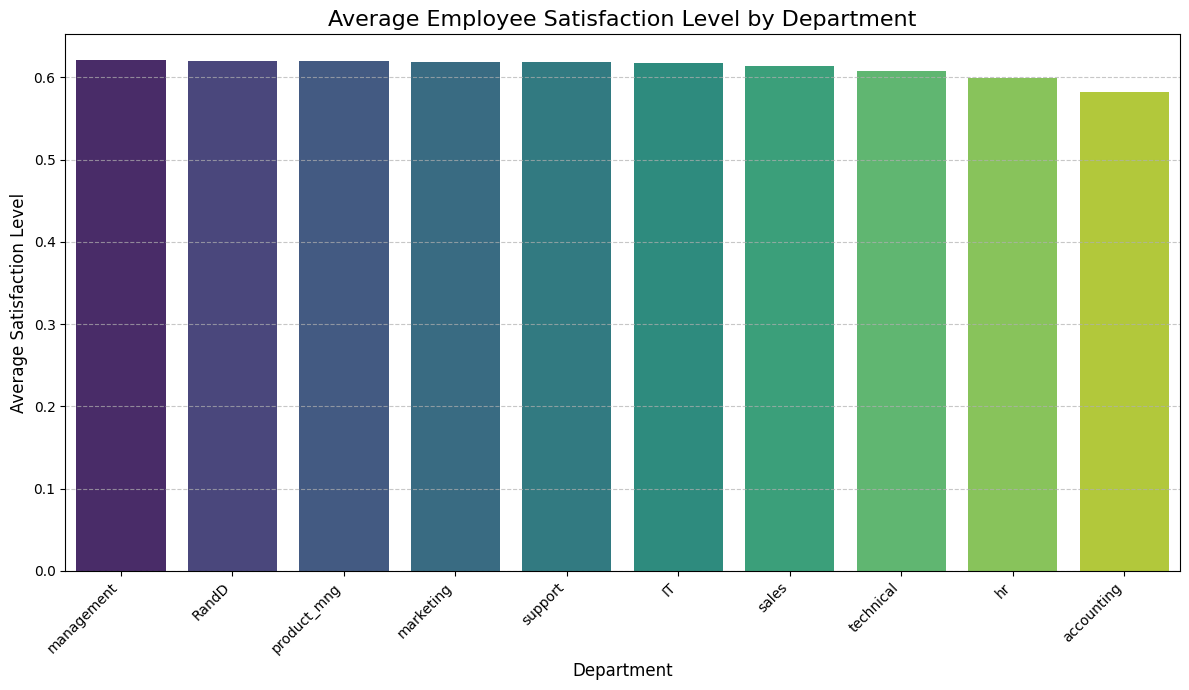

In [4]:
# Calculate average satisfaction level by department
avg_satisfaction_by_dept = df.groupby('sales')['satisfaction_level'].mean().sort_values(ascending=False)

# Create the bar chart
plt.figure(figsize=(12, 7))
sns.barplot(x=avg_satisfaction_by_dept.index, y=avg_satisfaction_by_dept.values, palette='viridis')
plt.title('Average Employee Satisfaction Level by Department', fontsize=16)
plt.xlabel('Department', fontsize=12)
plt.ylabel('Average Satisfaction Level', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/tmp/ipykernel_12023/251440024.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_satisfaction_by_dept_worst.index, y=avg_satisfaction_by_dept_worst.values, palette='plasma')


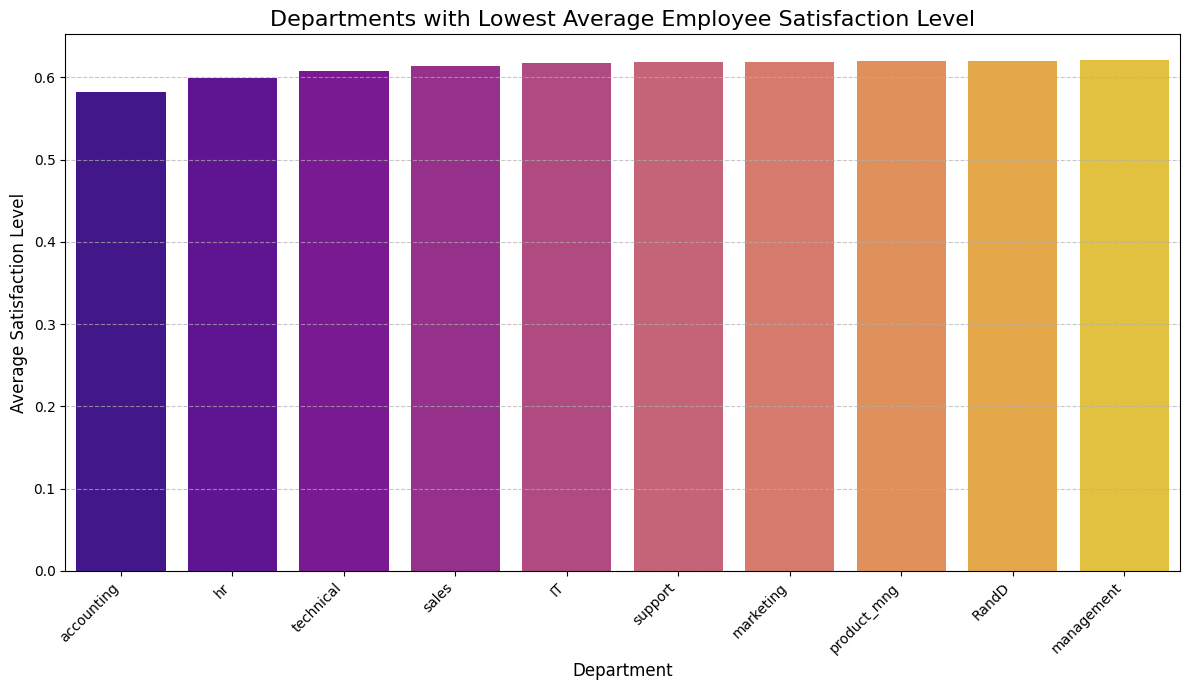

In [5]:
# Calculate average satisfaction level by department, sorted in ascending order for worst results
avg_satisfaction_by_dept_worst = df.groupby('sales')['satisfaction_level'].mean().sort_values(ascending=True)

# Create the bar chart for worst results
plt.figure(figsize=(12, 7))
sns.barplot(x=avg_satisfaction_by_dept_worst.index, y=avg_satisfaction_by_dept_worst.values, palette='plasma')
plt.title('Departments with Lowest Average Employee Satisfaction Level', fontsize=16)
plt.xlabel('Department', fontsize=12)
plt.ylabel('Average Satisfaction Level', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Top 10 Departments by Dissatisfaction Level:


,Dissatisfaction Level
sales,
accounting,0.417849
hr,0.401191
technical,0.392103
sales,0.385553
IT,0.381858
support,0.381700
marketing,0.381399
product_mng,0.380366
RandD,0.380178


/tmp/ipykernel_12023/5443732.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_dissatisfied_dept.index, y=top_10_dissatisfied_dept.values, palette='Reds_d')


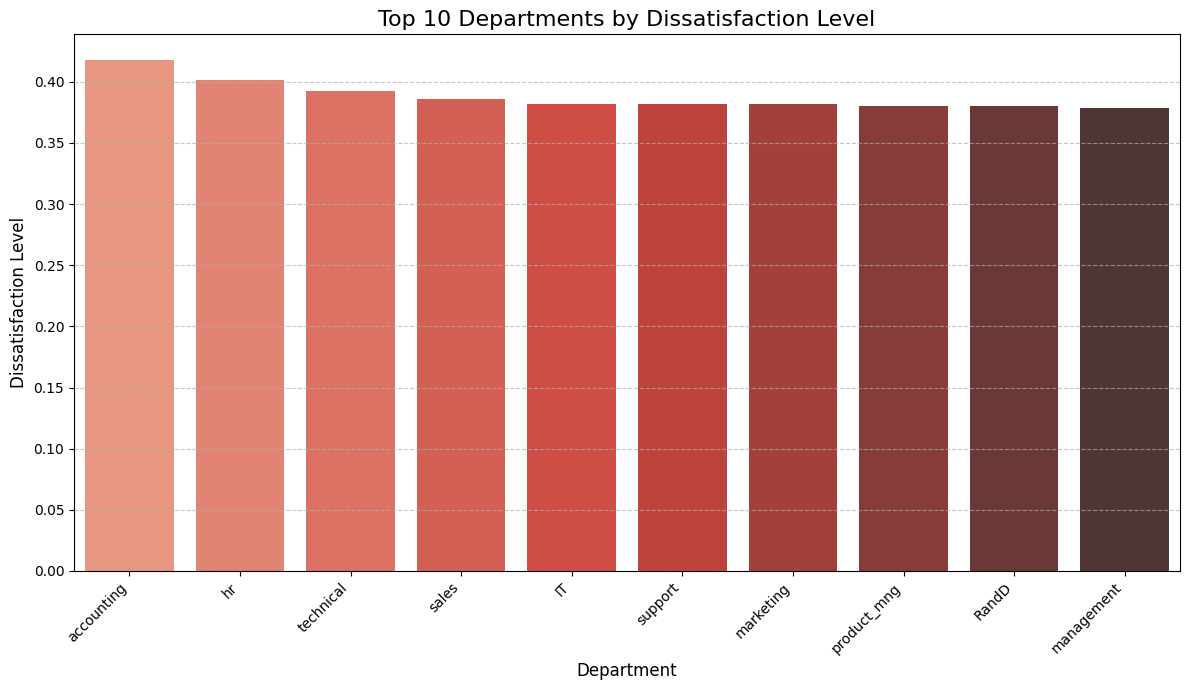

In [6]:
# Calculate dissatisfaction level (1 - satisfaction_level)
dissatisfaction_by_dept = 1 - avg_satisfaction_by_dept_worst

# Get the top 10 departments with the highest dissatisfaction
top_10_dissatisfied_dept = dissatisfaction_by_dept.head(10)

print("Top 10 Departments by Dissatisfaction Level:")
display(top_10_dissatisfied_dept.to_frame(name='Dissatisfaction Level'))

# Create a bar chart for the top 10 dissatisfied departments
plt.figure(figsize=(12, 7))
sns.barplot(x=top_10_dissatisfied_dept.index, y=top_10_dissatisfied_dept.values, palette='Reds_d')
plt.title('Top 10 Departments by Dissatisfaction Level', fontsize=16)
plt.xlabel('Department', fontsize=12)
plt.ylabel('Dissatisfaction Level', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Top 10 Departments with Highest Satisfaction Levels (Good Results)

Top 10 Departments by Satisfaction Level:


,Satisfaction Level
sales,
management,0.621349
RandD,0.619822
product_mng,0.619634
marketing,0.618601
support,0.618300
IT,0.618142
sales,0.614447
technical,0.607897
hr,0.598809


/tmp/ipykernel_12023/4107558467.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_satisfied_dept.index, y=top_10_satisfied_dept.values, palette='Greens_d')


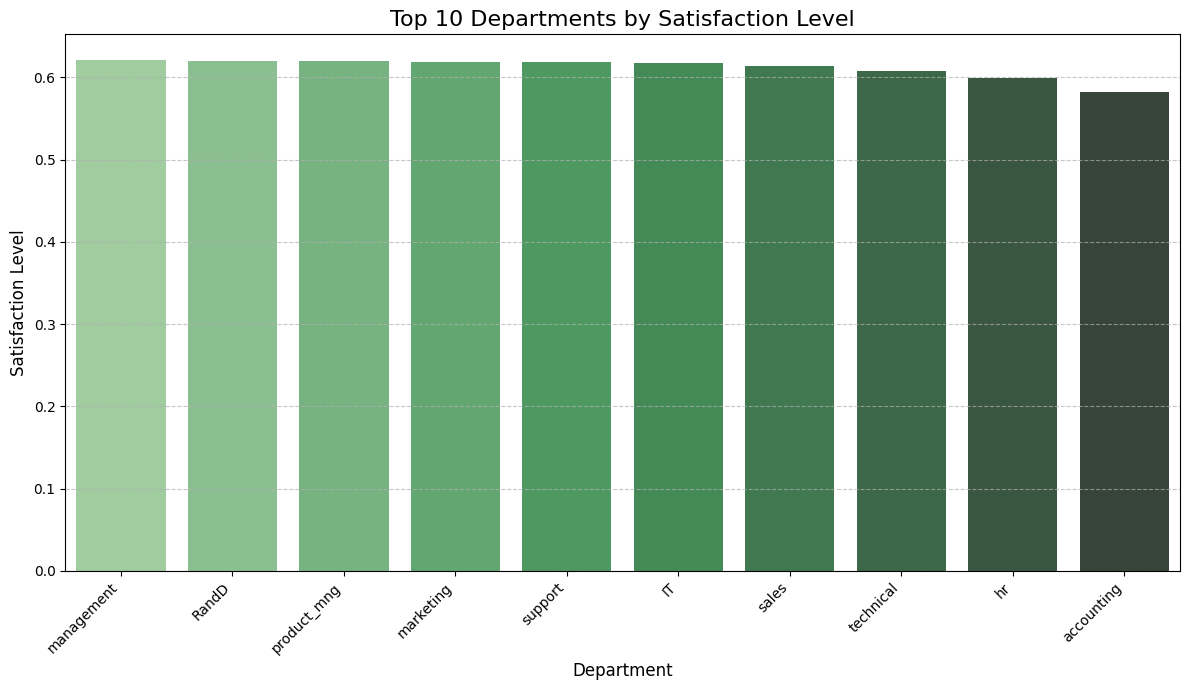

In [8]:
# Get the top 10 departments with the highest satisfaction
top_10_satisfied_dept = avg_satisfaction_by_dept.head(10)

print("Top 10 Departments by Satisfaction Level:")
display(top_10_satisfied_dept.to_frame(name='Satisfaction Level'))

# Create a bar chart for the top 10 satisfied departments
plt.figure(figsize=(12, 7))
sns.barplot(x=top_10_satisfied_dept.index, y=top_10_satisfied_dept.values, palette='Greens_d')
plt.title('Top 10 Departments by Satisfaction Level', fontsize=16)
plt.xlabel('Department', fontsize=12)
plt.ylabel('Satisfaction Level', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Top 10 Departments with Highest Dissatisfaction Levels (Bad Results)

Top 10 Departments by Dissatisfaction Level (repeated for clarity):


,Dissatisfaction Level
sales,
accounting,0.417849
hr,0.401191
technical,0.392103
sales,0.385553
IT,0.381858
support,0.381700
marketing,0.381399
product_mng,0.380366
RandD,0.380178


/tmp/ipykernel_12023/4291336135.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_dissatisfied_dept.index, y=top_10_dissatisfied_dept.values, palette='Reds_d')


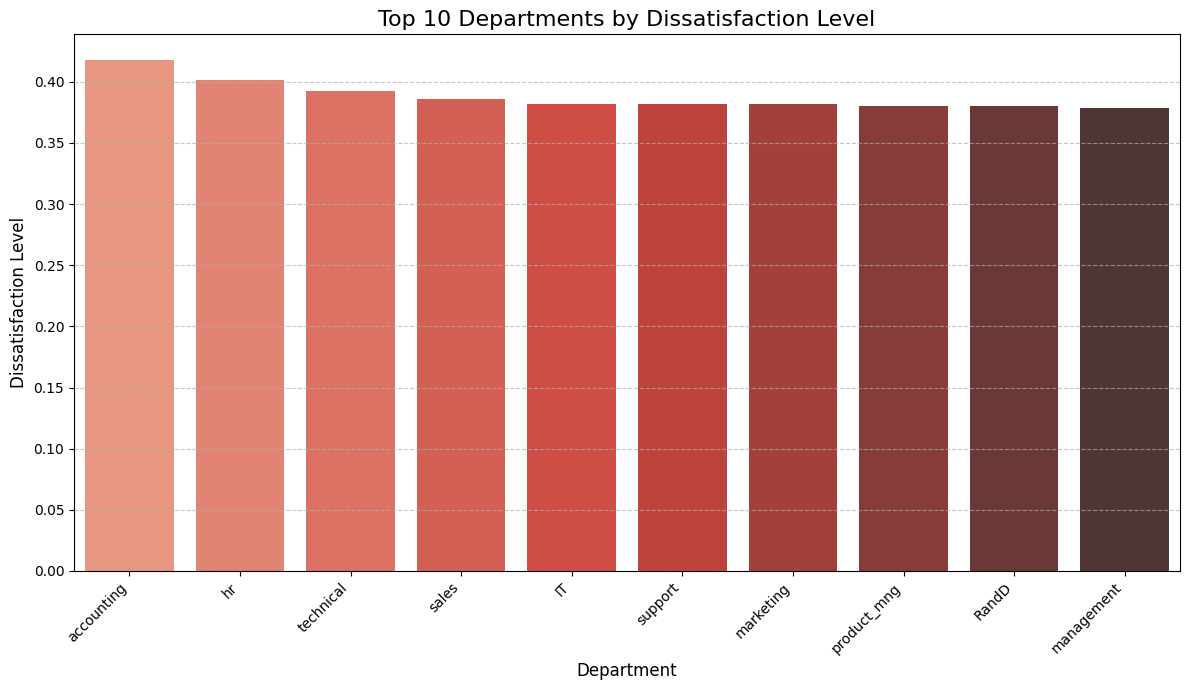

In [7]:
# Display the top 10 dissatisfied departments again for comparison
print("Top 10 Departments by Dissatisfaction Level (repeated for clarity):")
display(top_10_dissatisfied_dept.to_frame(name='Dissatisfaction Level'))

# Create a bar chart for the top 10 dissatisfied departments again
plt.figure(figsize=(12, 7))
sns.barplot(x=top_10_dissatisfied_dept.index, y=top_10_dissatisfied_dept.values, palette='Reds_d')
plt.title('Top 10 Departments by Dissatisfaction Level', fontsize=16)
plt.xlabel('Department', fontsize=12)
plt.ylabel('Dissatisfaction Level', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Main Departments for People Management Analysis (Summary):

These are the **top 10 departments with the highest satisfaction levels** (Good Results):

In [10]:
display(top_10_satisfied_dept.to_frame(name='Satisfaction Level'))

,Satisfaction Level
sales,
management,0.621349
RandD,0.619822
product_mng,0.619634
marketing,0.618601
support,0.618300
IT,0.618142
sales,0.614447
technical,0.607897
hr,0.598809


And these are the **top 10 departments with the highest dissatisfaction levels** (Bad Results):

In [9]:
display(top_10_dissatisfied_dept.to_frame(name='Dissatisfaction Level'))

,Dissatisfaction Level
sales,
accounting,0.417849
hr,0.401191
technical,0.392103
sales,0.385553
IT,0.381858
support,0.381700
marketing,0.381399
product_mng,0.380366
RandD,0.380178


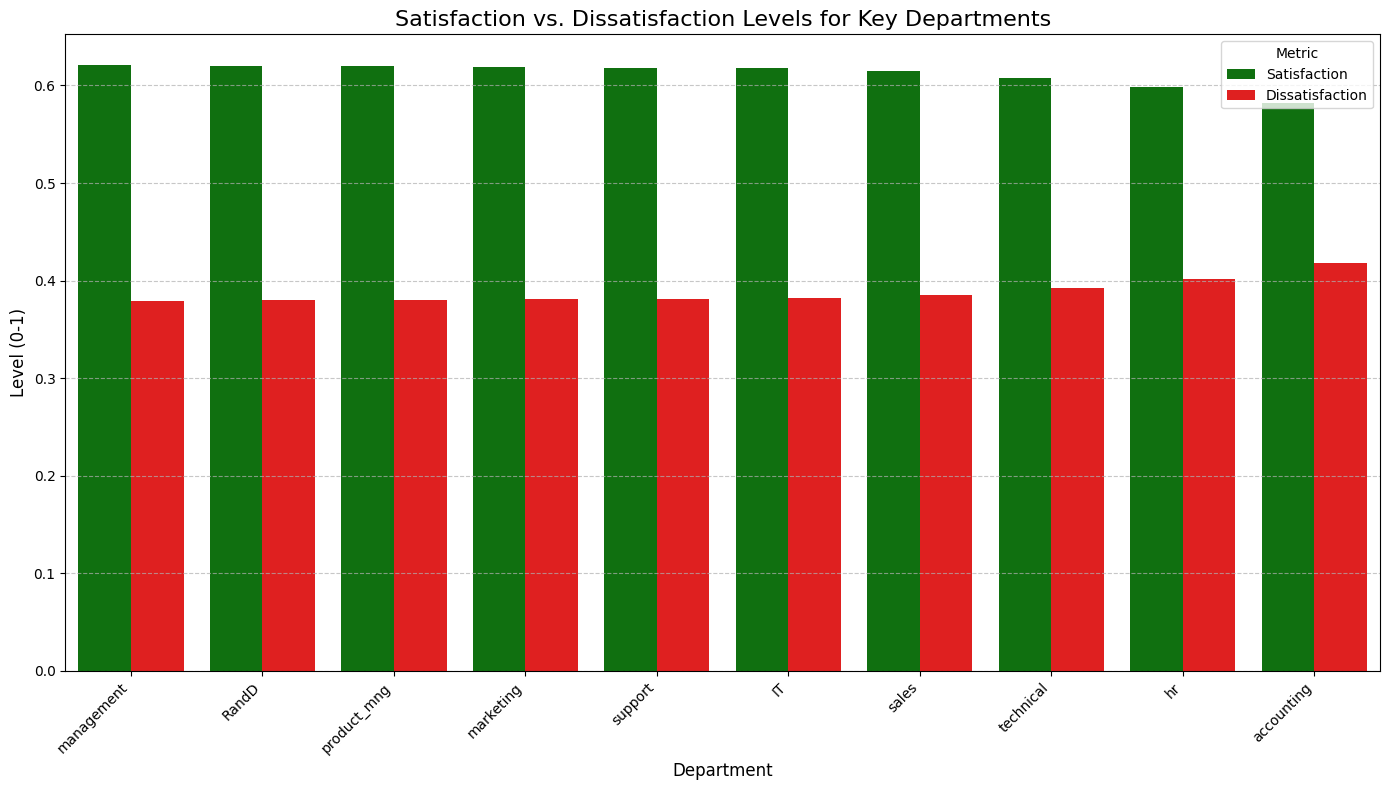

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Using the dissatisfaction_by_dept Series, which contains dissatisfaction for all departments, sorted.
# If the user specifically wants top 10, we can add .head(10) to dissatisfaction_by_dept

plt.figure(figsize=(12, 7))
sns.barplot(x=dissatisfaction_by_dept.index, y=dissatisfaction_by_dept.values, palette='Reds_d')
plt.title('Nível de Insatisfação por Departamento na Gestão de Pessoas', fontsize=16)
plt.xlabel('Departamento', fontsize=12)
plt.ylabel('Nível de Insatisfação', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/tmp/ipykernel_12023/251440024.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_satisfaction_by_dept_worst.index, y=avg_satisfaction_by_dept_worst.values, palette='plasma')


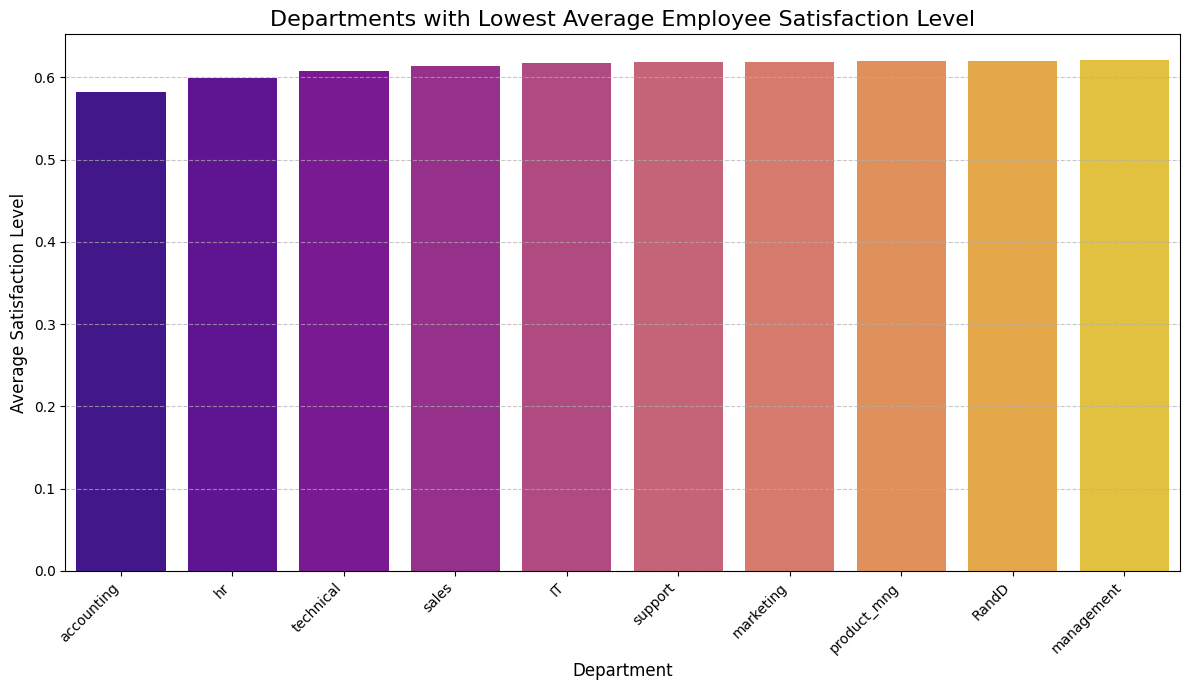

In [12]:
# Calculate average satisfaction level by department, sorted in ascending order for worst results
avg_satisfaction_by_dept_worst = df.groupby('sales')['satisfaction_level'].mean().sort_values(ascending=True)

# Create the bar chart for worst results
plt.figure(figsize=(12, 7))
sns.barplot(x=avg_satisfaction_by_dept_worst.index, y=avg_satisfaction_by_dept_worst.values, palette='plasma')
plt.title('Departments with Lowest Average Employee Satisfaction Level', fontsize=16)
plt.xlabel('Department', fontsize=12)
plt.ylabel('Average Satisfaction Level', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()